In [1]:
# Skipped in CI: Colab/bootstrap dependency install cell.


# Case Study: Bruco and ICA Noise Reduction

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/tatsuki-washimi/gwexpy/blob/main/docs/web/en/user_guide/tutorials/case_bruco_ica_denoising.ipynb)

This notebook demonstrates an end-to-end noise reduction workflow used in real interferometer commissioning:

1. **Bruco** – brute-force coherence scan to identify the most correlated auxiliary channels.
2. **ICA** – Independent Component Analysis to separate noise sources.
3. **Noise subtraction** – remove noise contributions from the DARM channel and compare ASDs.

This reproduces the workflow used in O4b commissioning (e.g., DARM 116 Hz line investigation).
The physical intent is to move from "which sensor sees the line" to "which latent source can be subtracted from DARM without destroying unrelated structure".

> **Prerequisites**: Familiarity with
> - [Bruco tutorial](advanced_bruco.ipynb) — Bruco basics
> - [PCA/ICA tutorial](advanced_decomposition.ipynb) — decomposition basics


## Setup

In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning)

import warnings
with warnings.catch_warnings():
    warnings.simplefilter('ignore')

    # ruff: noqa: I001
    import matplotlib.pyplot as plt
    import numpy as np
    from astropy import units as u

    from gwexpy.analysis import Bruco
    from gwexpy.timeseries import TimeSeries, TimeSeriesDict, TimeSeriesMatrix


## 1. Mock Data Generation

We simulate a scenario where the DARM channel contains:
- Broadband Gaussian noise (the "signal" floor)
- A 116 Hz line noise leaking from environmental sensors

Four PEM (Physical Environment Monitor) auxiliary channels each contain varying amounts
of the same 116 Hz line.  This mirrors the real O4b commissioning case.


In [3]:
rng = np.random.default_rng(42)

fs = 512        # sample rate [Hz]
T  = 64.0       # duration [s]
n  = int(fs * T)
t  = np.arange(n) / fs

FREQ_LINE = 116.0  # Hz — the line noise we want to remove

# ----- Independent sources -----
src_line  = np.sin(2 * np.pi * FREQ_LINE * t)   # coherent line noise
src_broad = rng.normal(0, 1, n)                  # broadband floor noise

# ----- DARM: broadband + line leakage -----
DARM_LINE_COUPLING = 0.5
darm_noise = src_broad + DARM_LINE_COUPLING * src_line

target = TimeSeries(
    darm_noise, dt=1 / fs, unit=u.dimensionless_unscaled,
    name="K1:CAL-CS_PROC_DARM_STRAIN_DBL_DQ", t0=0,
)

# ----- 4 auxiliary channels (different line content) -----
aux_configs = {
    "K1:PEM-ACC_PSL_TABLE_PSL1_Y": (0.9, 0.1),  # 90% line, 10% noise
    "K1:PEM-ACC_PSL_TABLE_PSL2_X": (0.7, 0.3),
    "K1:PEM-MIC_PSL_TABLE_PSL1_Z": (0.5, 0.5),
    "K1:PEM-MIC_PSL_TABLE_PSL2_Z": (0.2, 0.8),  # mostly noise
}

aux_dict = TimeSeriesDict({
    name: TimeSeries(
        a_line * src_line + a_noise * rng.normal(0, 1, n),
        dt=1 / fs, unit=u.dimensionless_unscaled, name=name, t0=0,
    )
    for name, (a_line, a_noise) in aux_configs.items()
        })

print(f"DARM   sample rate: {target.sample_rate}")
print(f"Aux channels: {list(aux_dict.keys())}")


DARM   sample rate: 512.0 Hz
Aux channels: ['K1:PEM-ACC_PSL_TABLE_PSL1_Y', 'K1:PEM-ACC_PSL_TABLE_PSL2_X', 'K1:PEM-MIC_PSL_TABLE_PSL1_Z', 'K1:PEM-MIC_PSL_TABLE_PSL2_Z']


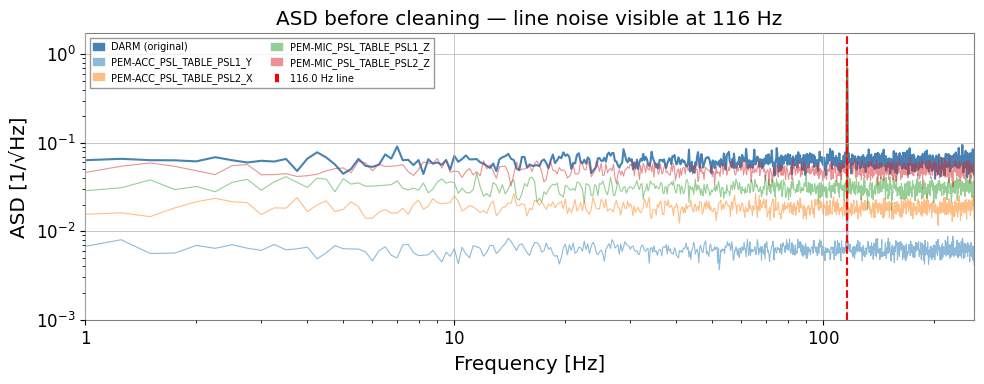

In [4]:
# Visualize the line noise in the ASD before cleaning
fig, ax = plt.subplots(figsize=(10, 4))
asd = target.asd(fftlength=4, overlap=2)
ax.loglog(asd.frequencies.value, asd.value, label="DARM (original)", color="steelblue")

for name, ts in aux_dict.items():
    a = ts.asd(fftlength=4, overlap=2)
    ax.loglog(a.frequencies.value, a.value, alpha=0.5, lw=0.8, label=name.split(":")[-1])

ax.axvline(FREQ_LINE, color="red", ls="--", label=f"{FREQ_LINE} Hz line")
ax.set_xlim(1, fs / 2)
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("ASD [1/√Hz]")
ax.set_title("ASD before cleaning — line noise visible at 116 Hz")
ax.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()


## 2. Bruco: Identify Correlated Auxiliary Channels

`Bruco.compute()` scans all auxiliary channels and returns the top-*N* most coherent
channels at each frequency.  This is the **first stage** of the pipeline:
identify *which* sensors see the same noise as DARM.

> **Common mistake**: feeding every available witness into ICA. Bruco is used here as a physics filter so the decomposition focuses on channels that plausibly share the 116 Hz contamination.


In [5]:
bruco = Bruco(target_channel=target.name, aux_channels=[])

result = bruco.compute(
    fftlength=4.0,
    overlap=2.0,
    target_data=target,
    aux_data=aux_dict,
    top_n=4,         # keep top-4 channels per frequency bin
)

print("Bruco scan complete.")
print(f"Result type: {type(result)}")


Bruco scan complete.
Result type: <class 'gwexpy.analysis.bruco.BrucoResult'>


In [6]:
# Show top channels near the 116 Hz line
df = result.to_dataframe(ranks=[0])
df_line = (
    df[df["frequency"].between(114, 118)]
    .sort_values("coherence", ascending=False)
    .dropna(subset=["channel"])
    .head(10)
    .reset_index(drop=True)
)
print("Top correlated channels near 116 Hz:")
df_line


Top correlated channels near 116 Hz:


,frequency,rank,channel,coherence,projection
0,116.00,1,K1:PEM-ACC_PSL_TABLE_PSL1_Y,0.995049,0.696766
1,115.75,1,K1:PEM-ACC_PSL_TABLE_PSL1_Y,0.984059,0.334223
2,116.25,1,K1:PEM-ACC_PSL_TABLE_PSL1_Y,0.979161,0.333768
3,114.75,1,K1:PEM-ACC_PSL_TABLE_PSL1_Y,0.459202,0.029435
4,116.75,1,K1:PEM-ACC_PSL_TABLE_PSL2_X,0.403842,0.024020
5,115.00,1,K1:PEM-ACC_PSL_TABLE_PSL1_Y,0.330589,0.020492
6,117.00,1,K1:PEM-ACC_PSL_TABLE_PSL2_X,0.293278,0.020808
7,117.50,1,K1:PEM-ACC_PSL_TABLE_PSL1_Y,0.271092,0.016356
8,114.50,1,K1:PEM-ACC_PSL_TABLE_PSL1_Y,0.269835,0.020907
9,115.50,1,K1:PEM-MIC_PSL_TABLE_PSL1_Z,0.246493,0.014666


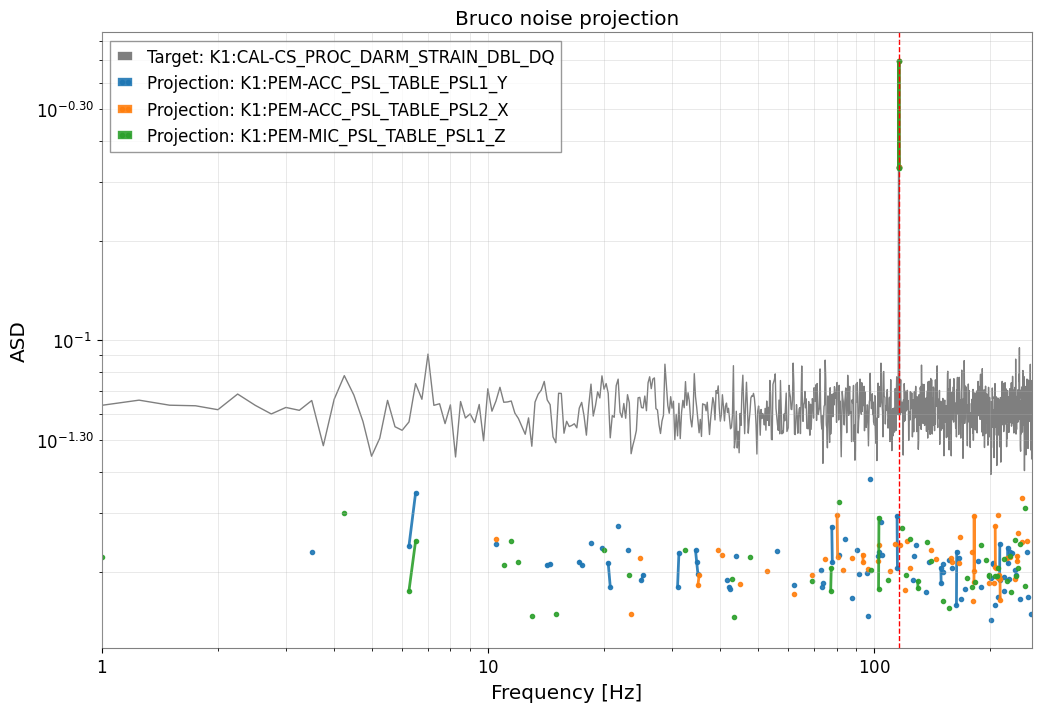

In [7]:
# Coherence projection plot — shows which channels dominate at each frequency
result.plot_projection(coherence_threshold=0.3)
plt.xlim(1, fs / 2)
plt.axvline(FREQ_LINE, color="red", ls="--", lw=1)
plt.title("Bruco noise projection")
plt.show()


## 3. ICA: Separate Noise Sources

From the Bruco scan we know which channels are highly coherent with DARM near 116 Hz.
We now stack these channels into a `TimeSeriesMatrix` and apply **ICA** to unmix the
underlying independent sources.

The ICA model gives us a *mixing matrix* **A** such that:
```
X = S · A^T   (X: observed channels, S: independent sources)
```
We can then subtract the noise-source contributions from DARM.

> **Failure mode to watch for**: ICA components are not automatically ordered by physical importance, and the sign / scale of each component is arbitrary. Always inspect spectra and channel loadings before deciding which component represents the line you want to subtract.


> **Note — ICA convergence**: FastICA may not converge within the default number of iterations on some datasets. If a `ConvergenceWarning` appears, consider increasing `max_iter` or `tol` in the ICA parameters. Results may still be usable even without full convergence.
>
> A second common failure mode is rank deficiency: if you feed nearly identical witnesses into ICA, the decomposition becomes unstable and the subtraction weights are hard to trust. Prefer a small set of informative but not perfectly redundant channels.


In [8]:
# Pick the top-2 channels from Bruco result
TOP_CHANNELS = df_line["channel"].dropna().unique()[:2].tolist()
print("Selected channels for ICA:", TOP_CHANNELS)

# Stack DARM + top channels into a TimeSeriesMatrix  (shape: n_ch × 1 × n_samples)
channels = [target] + [aux_dict[ch] for ch in TOP_CHANNELS]
data_3d = np.stack([ch.value for ch in channels], axis=0)[:, np.newaxis, :]

tsm = TimeSeriesMatrix(
    data_3d, dt=1 / fs, unit=u.dimensionless_unscaled, t0=0,
)
print(f"TimeSeriesMatrix shape: {tsm.shape}  (n_channels × 1 × n_samples)")


Selected channels for ICA: ['K1:PEM-ACC_PSL_TABLE_PSL1_Y', 'K1:PEM-ACC_PSL_TABLE_PSL2_X']
TimeSeriesMatrix shape: (3, 1, 32768)  (n_channels × 1 × n_samples)


ICA stopped after 200 iterations
Mixing matrix A shape: (3, 3)


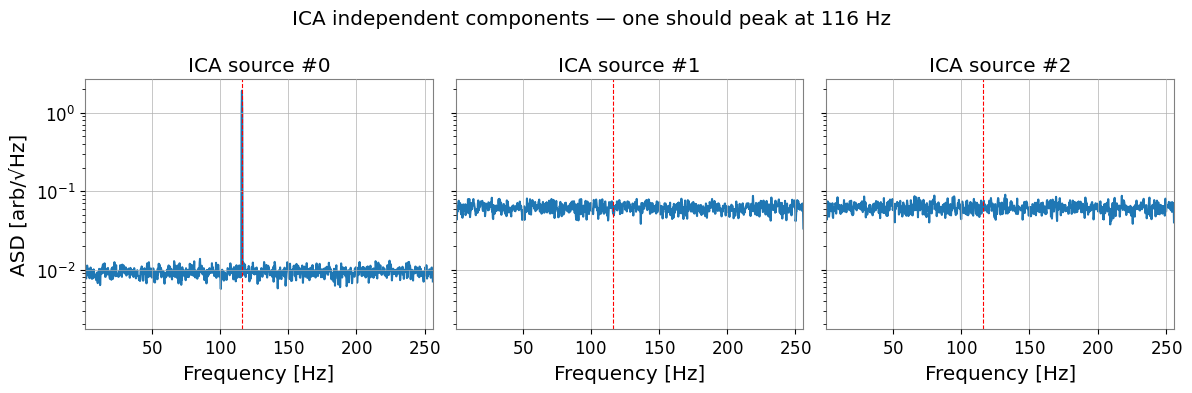

In [9]:
import warnings
with warnings.catch_warnings():
    warnings.simplefilter('ignore')

    # Run ICA
    n_components = len(channels)
    ica_sources, ica_model = tsm.ica(n_components=n_components, return_model=True)

    sk = ica_model.sklearn_model
    print(f"ICA stopped after {sk.n_iter_} iterations")
    print(f"Mixing matrix A shape: {sk.mixing_.shape}")  # (n_channels, n_components)

    # Visualize ICA sources in frequency domain
    fig, axes = plt.subplots(1, n_components, figsize=(4 * n_components, 4), sharey=True)
    for k in range(n_components):
        src_ts = TimeSeries(
            ica_sources.value[k, 0, :], dt=1 / fs,
            unit=u.dimensionless_unscaled, t0=0,
        )
        asd_k = src_ts.asd(fftlength=4, overlap=2)
        axes[k].semilogy(asd_k.frequencies.value, asd_k.value)
        axes[k].axvline(FREQ_LINE, color="red", ls="--", lw=0.8)
        axes[k].set_title(f"ICA source #{k}")
        axes[k].set_xlim(1, fs / 2)
        axes[k].set_xlabel("Frequency [Hz]")

    axes[0].set_ylabel("ASD [arb/√Hz]")
    plt.suptitle("ICA independent components — one should peak at 116 Hz")
    plt.tight_layout()
    plt.show()


## 4. Noise Subtraction and ASD Comparison

Identify which ICA components contain the 116 Hz line (by inspecting the ASD),
then subtract their contribution from DARM using the mixing matrix.

```
DARM_clean = DARM - Σ_k  A[0, k] · S_k(t)     (summed over noise components k)
```

> **Common mistake**: subtracting every ICA component that looks non-Gaussian. Only subtract components whose spectral content and witness loadings match the targeted coupling mechanism; otherwise you risk removing unrelated detector structure along with the line.


In [10]:
# Identify the noise component: the one with the largest ASD at FREQ_LINE
fftlength = 4.0
overlap   = 2.0
freqs = np.fft.rfftfreq(int(fftlength * fs), d=1 / fs)
line_bin = np.argmin(np.abs(freqs - FREQ_LINE))

A = sk.mixing_           # (n_channels, n_components)
X_raw = data_3d[:, 0, :].T   # (n_samples, n_channels)
S = sk.transform(X_raw)       # (n_samples, n_components)

# ASD of each component at the line frequency
asd_at_line = []
for k in range(n_components):
    s_ts = TimeSeries(S[:, k], dt=1 / fs, unit=u.dimensionless_unscaled, t0=0)
    asd_k = s_ts.asd(fftlength=fftlength, overlap=overlap)
    val = float(np.interp(FREQ_LINE, asd_k.frequencies.value, asd_k.value))
    asd_at_line.append(val)

noise_component = int(np.argmax(asd_at_line))
print(f"Dominant noise component: #{noise_component}  (ASD at {FREQ_LINE} Hz = {asd_at_line[noise_component]:.4f})")

# Subtract noise component from DARM (channel index 0)
darm_clean = X_raw[:, 0] - A[0, noise_component] * S[:, noise_component]
target_clean = TimeSeries(
    darm_clean, dt=1 / fs, unit=u.dimensionless_unscaled,
    name="DARM_cleaned", t0=0,
)


Dominant noise component: #0  (ASD at 116.0 Hz = 1.5728)


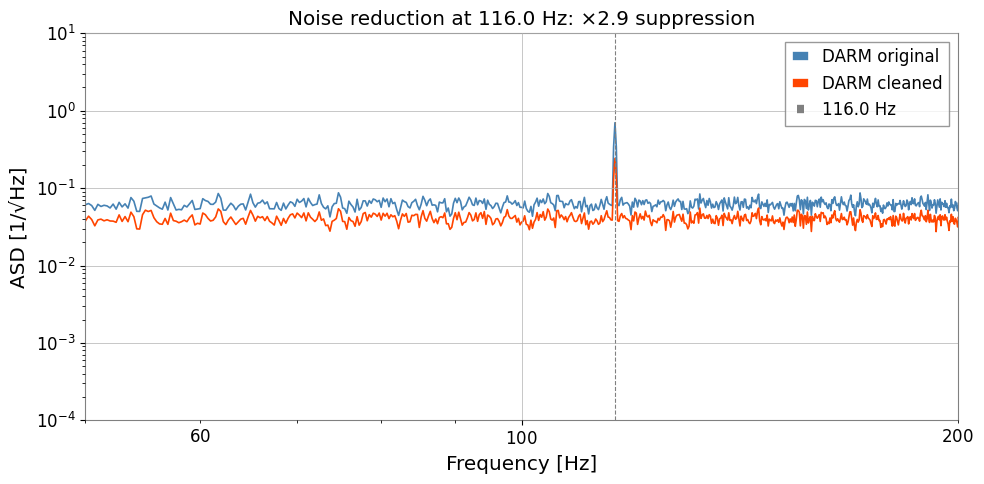

Suppression factor at 116.0 Hz: 2.89×


In [11]:
# Compare original vs cleaned ASD
asd_orig  = target.asd(fftlength=fftlength, overlap=overlap)
asd_clean = target_clean.asd(fftlength=fftlength, overlap=overlap)

fig, ax = plt.subplots(figsize=(10, 5))
ax.loglog(asd_orig.frequencies.value,  asd_orig.value,  label="DARM original",  color="steelblue", lw=1.2)
ax.loglog(asd_clean.frequencies.value, asd_clean.value, label="DARM cleaned",   color="orangered",  lw=1.2)
ax.axvline(FREQ_LINE, color="gray", ls="--", lw=0.8, label=f"{FREQ_LINE} Hz")

# Suppression factor at line frequency
ratio = float(np.interp(FREQ_LINE, asd_orig.frequencies.value, asd_orig.value)) /         float(np.interp(FREQ_LINE, asd_clean.frequencies.value, asd_clean.value))
ax.set_xlim(50, 200)
ax.set_ylim(1e-4, 10)
ax.set_xlabel("Frequency [Hz]")
ax.set_ylabel("ASD [1/√Hz]")
ax.set_title(f"Noise reduction at {FREQ_LINE} Hz: ×{ratio:.1f} suppression")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Suppression factor at {FREQ_LINE} Hz: {ratio:.2f}×")


## Summary

| Step | Tool | Output |
|------|------|--------|
| 1. Coherence scan | `Bruco.compute()` | Top correlated channels at each frequency |
| 2. Source separation | `TimeSeriesMatrix.ica()` | Independent components + mixing matrix |
| 3. Noise subtraction | Mixing matrix algebra | Cleaned DARM channel |

### Key takeaways

- **Bruco** efficiently narrows down thousands of channels to the few that matter.
- **ICA** goes beyond coherence: it separates *independent* source contributions even when
  multiple sensors share a common noise.
- The mixing matrix `A` provides a direct subtraction formula without time-domain filtering.
- Stable subtraction depends on witness selection and component identification, not on the ICA solver alone.

### Next steps

- Replace mock data with real NDS/GWF data (`TimeSeries.read()` or NDS2).
- Run on longer segments and cross-validate with Bruco's projection estimate.
- Combine with `Spectrogram.normalize()` (SNR spectrogram) to track the line over time.
